<a href="https://colab.research.google.com/github/unknown-here-now/Seasonal-Agricultural-Analytics-/blob/main/Seasonal_Agriculture_Performance_Data_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Seasonal Agriculture Performance Analysis
## Major Data Analytics Project
- **Domain:** Agriculture
- **Project Theme:** Seasonal Agriculture Performance
- **Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn

### Project Goal
Investigate how agricultural performance varies across seasons and identify meaningful patterns, trends, relationships, and differences in the available data.
*Note: This is a pure Data Analytics project. No Machine Learning or dashboard development is required.*

---
### 1. Problem Statement
Agricultural activities are influenced by seasonal variations in environmental conditions, farming practices, resource availability, and market conditions. As a result, agricultural performance may differ from one season to another. The problem is to analyze the given agricultural dataset and investigate seasonal differences by identifying meaningful patterns, trends, relationships, and variations.

### 2. Project Objectives
- Understand the structure and quality of the agricultural dataset.
- Clean and prepare the data for analysis.
- Explore seasonal patterns across environmental and production metrics.
- Compare resource usage (water, fertilizer, pesticide) across seasons.
- Investigate relationships among relevant variables (weather, inputs, yields, economics).
- Apply appropriate univariate, bivariate, and multivariate visualizations.
- Identify significant findings and derive 8+ evidence-based insights.
- Develop data-driven recommendations and document limitations.

### 3. Dataset
Dataset file: `seasonal_agriculture_performance_dataset.csv`

In [ ]:
# Import required libraries
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

%matplotlib inline
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

# Load the dataset
file_path = 'seasonal_agriculture_performance_dataset.csv'
df = pd.read_csv(file_path)
print('Dataset loaded successfully!')

Dataset loaded successfully!


### 4. Initial Data Understanding

In [ ]:
# Dataset shape
print(f'Number of rows: {df.shape[0]}')
print(f'Number of columns: {df.shape[1]}')

# Top 5 rows
df.head()

Number of rows: 4000
Number of columns: 28


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.40,24.30,69.10,5.80,7.14,32.80,75.80,61.30,91.00,Drip,242.70,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.49,55.30
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.40,25.70,78.40,5.10,5.20,32.00,82.10,35.40,121.80,Flood,271.40,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.40,49.90
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.60,23.90,56.40,10.30,5.82,8.10,118.50,51.50,117.90,Drip,162.60,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.98,33.70
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.20,29.70,65.20,6.30,5.98,23.70,138.60,55.60,115.50,Rainfed,182.20,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.16,50.60
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.60,34.10,55.20,6.50,6.90,29.30,124.10,69.00,121.40,Flood,244.90,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.83,32.30


In [ ]:
# Bottom 5 rows
df.tail()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
3995,SF13996,Karnataka,Rajkot,Wheat,Kharif,4.72,865.40,27.30,51.40,6.30,7.97,27.30,104.30,44.80,94.00,Drip,271.10,5.45,0.74,0.51,2.41,22717,362917,54748,-308169,2016,1.20,45.20
3996,SF13997,Karnataka,Krishna,Chilli,Kharif,8.77,947.50,29.20,85.50,6.10,6.57,33.70,127.80,44.90,91.30,Drip,176.60,4.99,0.80,2.75,24.12,106459,496471,2567791,2071320,5351,4.51,59.70
3997,SF13998,Andhra Pradesh,Erode,Pulses,Zaid,10.47,80.00,35.40,68.50,8.60,7.25,21.10,126.70,59.90,148.00,Drip,234.70,6.27,0.99,0.62,6.49,66860,785632,433921,-351711,3392,1.91,29.20
3998,SF13999,Punjab,Warangal,Cotton,Kharif,1.73,475.00,28.20,61.70,6.40,6.11,30.50,107.50,20.70,91.00,Sprinkler,329.70,2.60,0.98,1.35,2.34,75282,153904,176160,22256,1220,1.92,50.40
3999,SF14000,Punjab,Nashik,Wheat,Kharif,3.31,984.30,25.80,77.20,5.90,6.16,35.70,137.10,92.60,145.50,Sprinkler,205.90,6.72,0.99,2.36,7.81,28812,263872,225022,-38850,1800,4.34,62.30


In [ ]:
# Random sample of records
df.sample(5, random_state=42)

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
555,SF10556,Andhra Pradesh,Nashik,Chilli,Rabi,7.94,456.80,25.30,47.70,7.60,7.10,12.90,108.00,75.80,96.50,Flood,228.20,8.51,0.87,NaN,15.64,92892,619157,1452831,833674,6146,2.54,34.40
3491,SF13492,Punjab,Warangal,Wheat,Kharif,12.44,601.90,27.20,60.20,8.30,7.66,24.30,97.80,36.70,96.00,Drip,65.90,6.88,0.77,0.94,11.69,23614,680562,276048,-404514,5818,2.01,31.80
527,SF10528,Maharashtra,Indore,Cotton,Kharif,6.35,1213.70,26.30,73.60,7.10,6.33,30.40,149.30,41.80,98.80,Drip,143.00,5.63,0.69,1.17,7.43,69828,441813,518822,77009,4491,1.65,52.70
3925,SF13926,Madhya Pradesh,Nashik,Wheat,Rabi,12.52,374.00,17.90,59.70,9.40,7.57,24.50,118.60,77.50,128.70,Rainfed,116.40,5.14,0.71,0.88,11.02,26649,744970,293672,-451298,3347,3.29,29.80
2989,SF12990,Gujarat,Rajkot,Chilli,Rabi,13.98,197.80,19.00,55.80,9.20,7.31,18.90,45.80,79.90,126.70,Flood,242.80,4.87,0.95,1.07,14.96,108549,994707,1623893,629186,10975,1.36,39.60


In [ ]:
# Column names & Data types
print('Column Names:')
print(df.columns.tolist())
print('\nDataset Info:')
df.info()

Column Names:
['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   obj

In [ ]:
# Numerical and Categorical summary statistics
display(df.describe())
display(df.describe(include=['object']))

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,4000.00,3952.00,4000.00,4000.00,4000.00,4000.00,3960.00,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00,3968.00,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00
mean,7.89,601.15,26.82,63.21,7.32,6.70,26.51,120.25,57.78,104.76,186.04,5.07,0.83,5.27,43.25,44714.17,526303.58,637860.05,111556.46,6045.57,5.39,46.37
std,4.22,288.93,3.82,11.96,1.12,0.64,6.71,31.22,17.02,27.74,60.26,1.98,0.10,13.36,126.88,30266.16,294419.14,636974.71,545081.89,5572.94,8.84,12.42
min,0.50,80.00,16.20,25.00,3.50,5.20,8.00,40.00,15.00,30.00,40.00,0.50,0.65,0.30,0.15,2594.00,26826.00,6107.00,-1019223.00,128.00,0.14,5.00
25%,4.26,370.20,23.90,54.77,6.60,6.26,21.70,98.50,46.20,86.20,143.97,3.69,0.74,1.05,5.02,21429.25,274577.50,207517.25,-148731.75,2268.75,1.66,37.30
50%,7.89,582.00,26.90,63.00,7.30,6.69,26.40,120.10,57.50,105.10,186.25,5.12,0.83,1.74,11.77,25913.00,519082.50,456830.50,3673.00,4435.00,2.94,46.40
75%,11.65,834.95,29.60,71.90,8.10,7.14,31.30,141.22,69.40,123.60,227.20,6.40,0.91,2.84,24.36,68279.00,761996.50,836874.75,216187.75,7829.75,5.15,54.90
max,15.00,1395.20,39.70,95.00,11.00,8.40,47.00,220.00,120.00,200.00,400.00,12.08,1.00,101.44,1424.40,131240.00,1349990.00,5080900.00,4345421.00,40902.00,79.80,88.90


,Farm_ID,State,District,Crop,Season,Irrigation_Method
count,4000,4000,4000,4000,4000,4000
unique,4000,8,10,8,3,4
top,SF13984,Andhra Pradesh,Ludhiana,Rice,Kharif,Flood
freq,1,529,427,690,1779,1310


### 5. Data Quality Analysis & Data Cleaning

,Missing_Count,Missing_Percentage
Rainfall_mm,48,1.20
Soil_Moisture_pct,40,1.00
Yield_Tonnes_Ha,32,0.80


/tmp/ipykernel_4957/2565170615.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


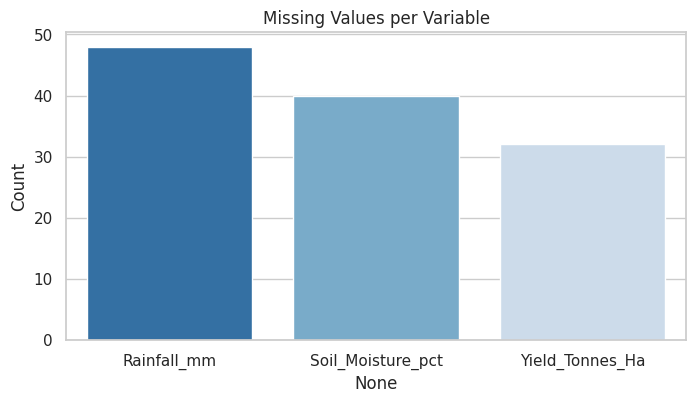

In [ ]:
# Missing value inspection
missing_count = df.isnull().sum()
missing_pct = (missing_count / len(df)) * 100
missing_summary = pd.DataFrame(
    {
        'Missing_Count': missing_count,
        'Missing_Percentage': missing_pct,
    }
)
missing_summary = missing_summary[
    missing_summary['Missing_Count'] > 0
].sort_values(by='Missing_Count', ascending=False)
display(missing_summary)

# Visualizing missing values
if len(missing_summary) > 0:
  plt.figure(figsize=(8, 4))
  sns.barplot(
      x=missing_summary.index,
      y=missing_summary['Missing_Count'],
      palette='Blues_r',
  )
  plt.title('Missing Values per Variable')
  plt.ylabel('Count')
  plt.show()

In [ ]:
# Duplicate records check and handling
duplicate_count = df.duplicated().sum()
print(f'Number of duplicate rows: {duplicate_count}')
if duplicate_count > 0:
  df = df.drop_duplicates().reset_index(drop=True)
  print(f'Shape after removing duplicates: {df.shape}')

Number of duplicate rows: 0


In [ ]:
# Check unique values in categorical columns
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
  print(f'=== {col} ({df[col].nunique()} unique values) ===')
  print(df[col].value_counts().head(8))
  print()

=== Farm_ID (4000 unique values) ===
Farm_ID
SF13984    1
SF13983    1
SF13982    1
SF13981    1
SF13980    1
SF13979    1
SF13978    1
SF13977    1
Name: count, dtype: int64

=== State (8 unique values) ===
State
Andhra Pradesh    529
Telangana         516
Maharashtra       512
Madhya Pradesh    497
Karnataka         489
Gujarat           488
Tamil Nadu        485
Punjab            484
Name: count, dtype: int64

=== District (10 unique values) ===
District
Ludhiana    427
Warangal    422
Nalgonda    415
Erode       403
Rajkot      401
Krishna     393
Indore      392
Guntur      390
Name: count, dtype: int64

=== Crop (8 unique values) ===
Crop
Rice         690
Wheat        614
Maize        551
Cotton       508
Pulses       496
Groundnut    424
Chilli       412
Sugarcane    305
Name: count, dtype: int64

=== Season (3 unique values) ===
Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64

=== Irrigation_Method (4 unique values) ===
Irrigation_Method
Flood     

In [ ]:
# Missing value treatment using median imputation for numerical features
for col in missing_summary.index:
  median_val = df[col].median()
  df[col] = df[col].fillna(median_val)
  print(f"Imputed missing values in '{col}' with median: {median_val:.2f}")

print(f'Remaining missing values: {df.isnull().sum().sum()}')

Imputed missing values in 'Rainfall_mm' with median: 582.00
Imputed missing values in 'Soil_Moisture_pct' with median: 26.40
Imputed missing values in 'Yield_Tonnes_Ha' with median: 1.74
Remaining missing values: 0


### 6. Feature Categorization

In [ ]:
identifier_cols = ['Farm_ID']
categorical_cols = ['State', 'District', 'Crop', 'Season', 'Irrigation_Method']
environmental_cols = [
    'Rainfall_mm',
    'Avg_Temperature_C',
    'Humidity_pct',
    'Sunlight_Hours_Day',
    'Soil_pH',
    'Soil_Moisture_pct',
]
soil_nutrients = [
    'Nitrogen_kg_ha',
    'Phosphorus_kg_ha',
    'Potassium_kg_ha',
]
inputs_cols = [
    'Farm_Area_Hectares',
    'Fertilizer_kg_ha',
    'Pesticide_Litre_ha',
    'Seed_Quality_Score',
    'Water_Used_m3',
]
performance_cols = [
    'Yield_Tonnes_Ha',
    'Production_Tonnes',
    'Market_Price_INR_Tonne',
    'Total_Cost_INR',
    'Revenue_INR',
    'Profit_INR',
    'Water_Efficiency_t_per_1000m3',
    'Disease_Pest_Risk_pct',
]
print(f"Features categorized: {len(categorical_cols)} categorical, {len(environmental_cols)} environmental, {len(performance_cols)} performance metrics.")

Features categorized: 5 categorical, 6 environmental, 8 performance metrics.


### 7. Statistical Analysis

In [ ]:
# Numerical Summary with Mean, Median, Std Dev, Min, Max
num_cols = df.select_dtypes(include=[np.number]).columns
summary_stats = pd.DataFrame({
    'Mean': df[num_cols].mean(),
    'Median': df[num_cols].median(),
    'Std_Dev': df[num_cols].std(),
    'Min': df[num_cols].min(),
    'Max': df[num_cols].max(),
})
summary_stats.round(2)

,Mean,Median,Std_Dev,Min,Max
Farm_Area_Hectares,7.89,7.90,4.22,0.50,15.00
Rainfall_mm,600.92,582.00,287.19,80.00,1395.20
Avg_Temperature_C,26.82,26.90,3.82,16.20,39.70
Humidity_pct,63.21,63.00,11.96,25.00,95.00
Sunlight_Hours_Day,7.32,7.30,1.12,3.50,11.00
Soil_pH,6.70,6.69,0.64,5.20,8.40
Soil_Moisture_pct,26.51,26.40,6.68,8.00,47.00
Nitrogen_kg_ha,120.25,120.10,31.22,40.00,220.00
Phosphorus_kg_ha,57.78,57.50,17.02,15.00,120.00
Potassium_kg_ha,104.76,105.10,27.74,30.00,200.00


In [ ]:
# Seasonal descriptive summary
df.groupby('Season')[
    [
        'Yield_Tonnes_Ha',
        'Profit_INR',
        'Water_Used_m3',
        'Rainfall_mm',
    ]
].agg(['mean', 'median', 'std']).round(2)

Yield_Tonnes_Ha              Profit_INR                      \
                  mean median   std       mean    median       std   
Season                                                               
Kharif            5.63   1.94 14.39  178914.65  38808.00 611549.78   
Rabi              5.04   1.67 12.75   87689.47  -3187.00 489901.25   
Zaid              4.64   1.46 11.27  -24804.82 -62144.00 436356.75   

       Water_Used_m3                 Rainfall_mm                
                mean  median     std        mean median    std  
Season                                                          
Kharif       6102.20 4469.00 5670.58      849.20 853.10 183.69  
Rabi         5846.99 4292.00 5397.65      437.62 432.20 175.35  
Zaid         6419.89 4805.00 5734.62      304.65 288.20 157.24

### 8. Univariate Analysis

/tmp/ipykernel_4957/1397656818.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


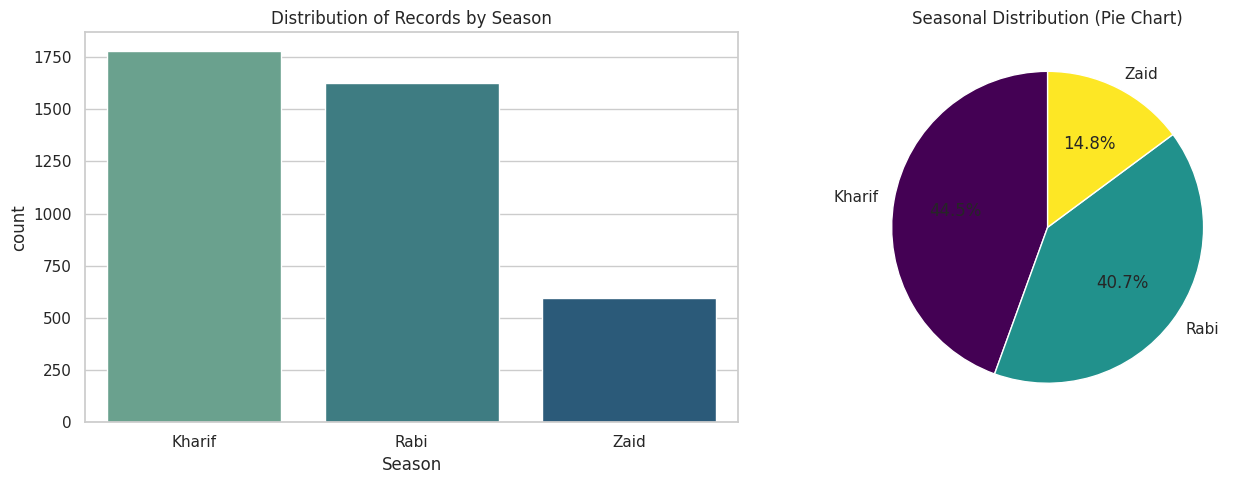

In [ ]:
# Season Distribution (Bar & Pie)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(
    data=df,
    x='Season',
    order=df['Season'].value_counts().index,
    ax=axes[0],
    palette='crest',
)
axes[0].set_title('Distribution of Records by Season')

df['Season'].value_counts().plot.pie(
    autopct='%1.1f%%', startangle=90, cmap='viridis', ax=axes[1]
)
axes[1].set_title('Seasonal Distribution (Pie Chart)')
axes[1].set_ylabel('')
plt.tight_layout()
plt.show()

/tmp/ipykernel_4957/103261291.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


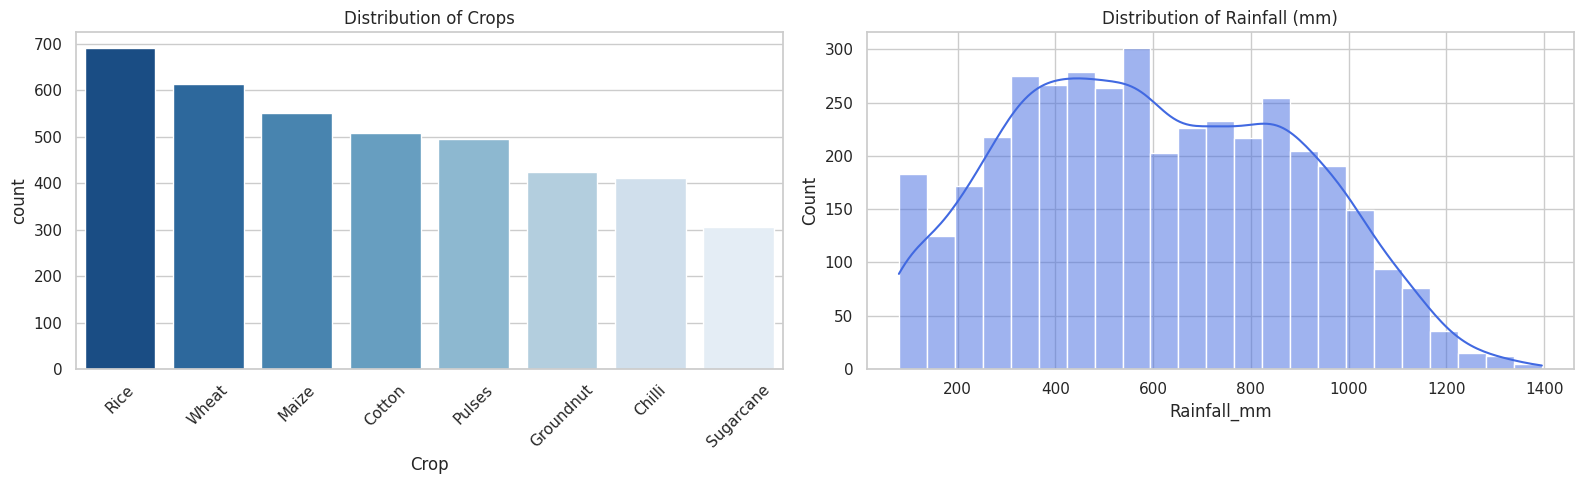

In [ ]:
# Crop and Rainfall Distributions
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.countplot(
    data=df,
    x='Crop',
    order=df['Crop'].value_counts().index,
    ax=axes[0],
    palette='Blues_r',
)
axes[0].set_title('Distribution of Crops')
axes[0].tick_params(axis='x', rotation=45)

sns.histplot(df['Rainfall_mm'], kde=True, ax=axes[1], color='royalblue')
axes[1].set_title('Distribution of Rainfall (mm)')
plt.tight_layout()
plt.show()

### 9. Outlier Analysis (IQR Method)

,Column,Lower_Bound,Upper_Bound,Outlier_Count,Outlier_Percentage
18,Profit_INR,-696111.00,763567.00,404,10.10
14,Production_Tonnes,-23.98,53.36,333,8.33
20,Water_Efficiency_t_per_1000m3,-3.57,10.38,322,8.05
13,Yield_Tonnes_Ha,-1.62,5.50,302,7.55
19,Water_Used_m3,-6072.75,16171.25,276,6.90
17,Revenue_INR,-736519.00,1780911.00,240,6.00
9,Potassium_kg_ha,30.10,179.70,32,0.80
4,Sunlight_Hours_Day,4.35,10.35,26,0.65
8,Phosphorus_kg_ha,11.40,104.20,16,0.40
10,Fertilizer_kg_ha,19.14,352.04,15,0.38


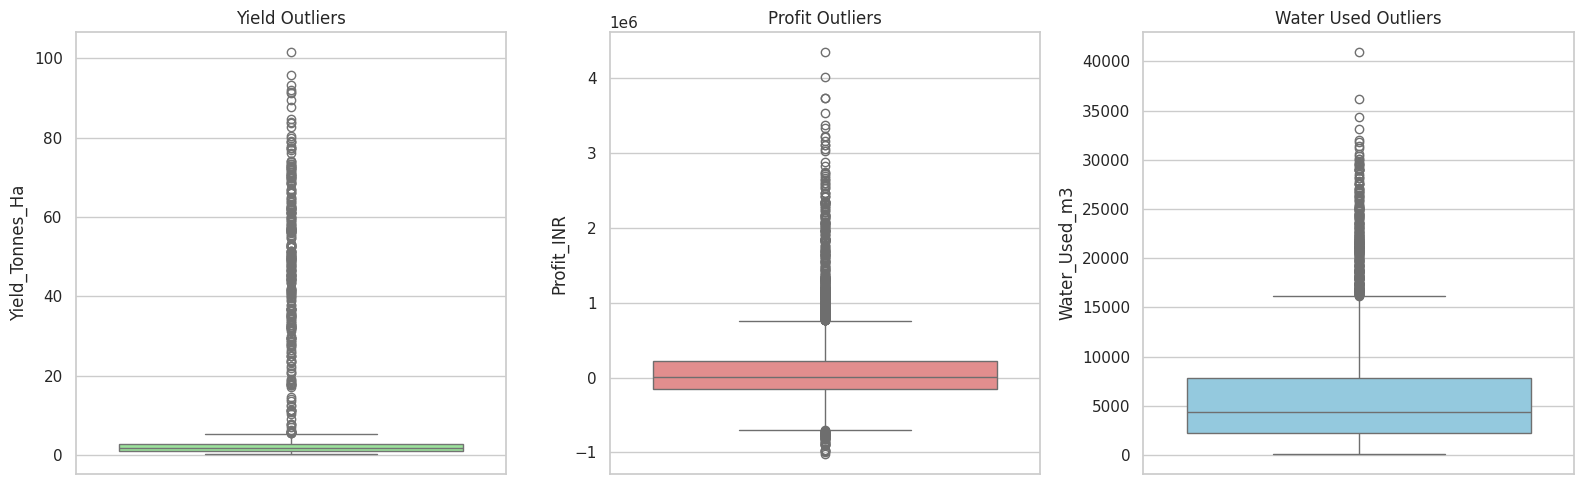

In [ ]:
# IQR-based Outlier Summary
outlier_summary = []
for col in num_cols:
  q1 = df[col].quantile(0.25)
  q3 = df[col].quantile(0.75)
  iqr = q3 - q1
  lower = q1 - 1.5 * iqr
  upper = q3 + 1.5 * iqr
  count = ((df[col] < lower) | (df[col] > upper)).sum()
  pct = (count / len(df)) * 100
  outlier_summary.append({
      'Column': col,
      'Lower_Bound': round(lower, 2),
      'Upper_Bound': round(upper, 2),
      'Outlier_Count': count,
      'Outlier_Percentage': round(pct, 2),
  })

outlier_df = pd.DataFrame(outlier_summary).sort_values(
    by='Outlier_Count', ascending=False
)
display(outlier_df.head(10))

# Boxplot visual for outliers
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
sns.boxplot(y=df['Yield_Tonnes_Ha'], ax=axes[0], color='lightgreen')
axes[0].set_title('Yield Outliers')
sns.boxplot(y=df['Profit_INR'], ax=axes[1], color='lightcoral')
axes[1].set_title('Profit Outliers')
sns.boxplot(y=df['Water_Used_m3'], ax=axes[2], color='skyblue')
axes[2].set_title('Water Used Outliers')
plt.tight_layout()
plt.show()

### 10. Bivariate Analysis

/tmp/ipykernel_4957/814020131.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Season', y='Yield_Tonnes_Ha', ax=axes[0], palette='Set2')
/tmp/ipykernel_4957/814020131.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Season', y='Profit_INR', ax=axes[1], palette='Set2')


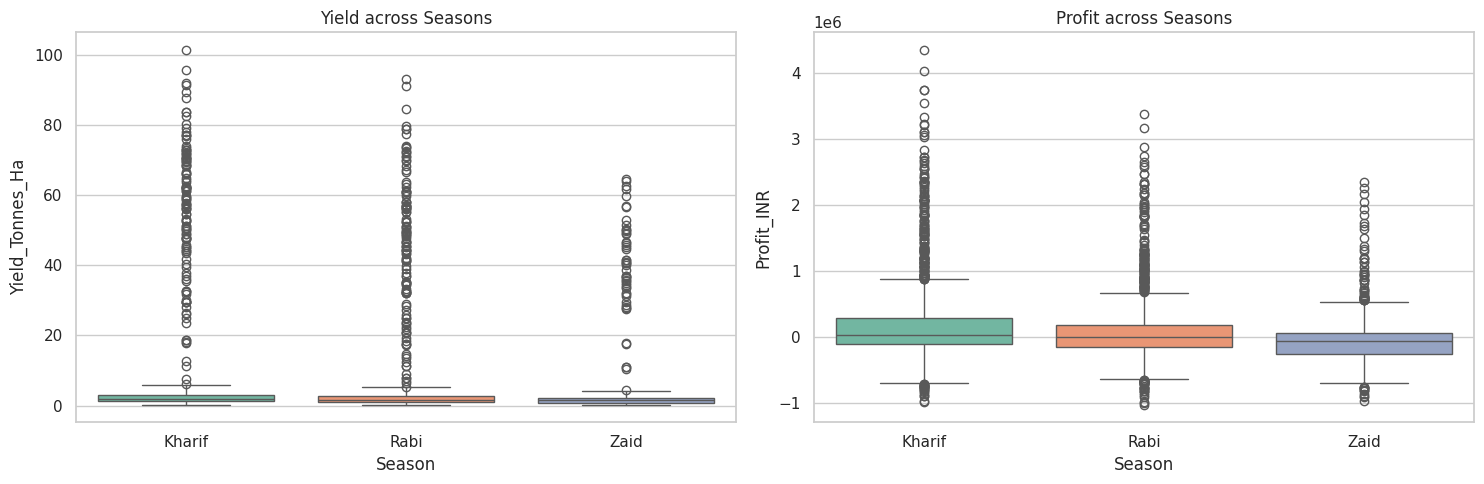

In [ ]:
# Season vs Yield and Season vs Profit
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.boxplot(data=df, x='Season', y='Yield_Tonnes_Ha', ax=axes[0], palette='Set2')
axes[0].set_title('Yield across Seasons')

sns.boxplot(data=df, x='Season', y='Profit_INR', ax=axes[1], palette='Set2')
axes[1].set_title('Profit across Seasons')
plt.tight_layout()
plt.show()

/tmp/ipykernel_4957/164259170.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Season', y='Water_Used_m3', ax=axes[0], palette='Blues')
/tmp/ipykernel_4957/164259170.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Irrigation_Method', y='Yield_Tonnes_Ha', ax=axes[1], palette='Greens')


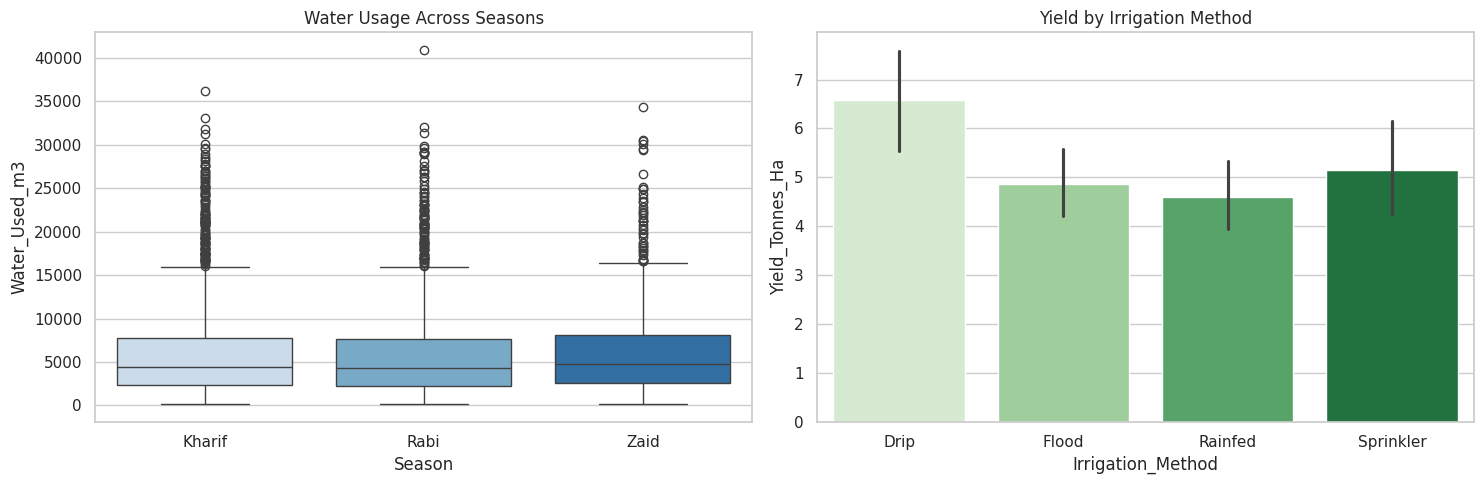

In [ ]:
# Water Used Across Seasons & Irrigation Method vs Yield
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.boxplot(data=df, x='Season', y='Water_Used_m3', ax=axes[0], palette='Blues')
axes[0].set_title('Water Usage Across Seasons')

sns.barplot(data=df, x='Irrigation_Method', y='Yield_Tonnes_Ha', ax=axes[1], palette='Greens')
axes[1].set_title('Yield by Irrigation Method')
plt.tight_layout()
plt.show()

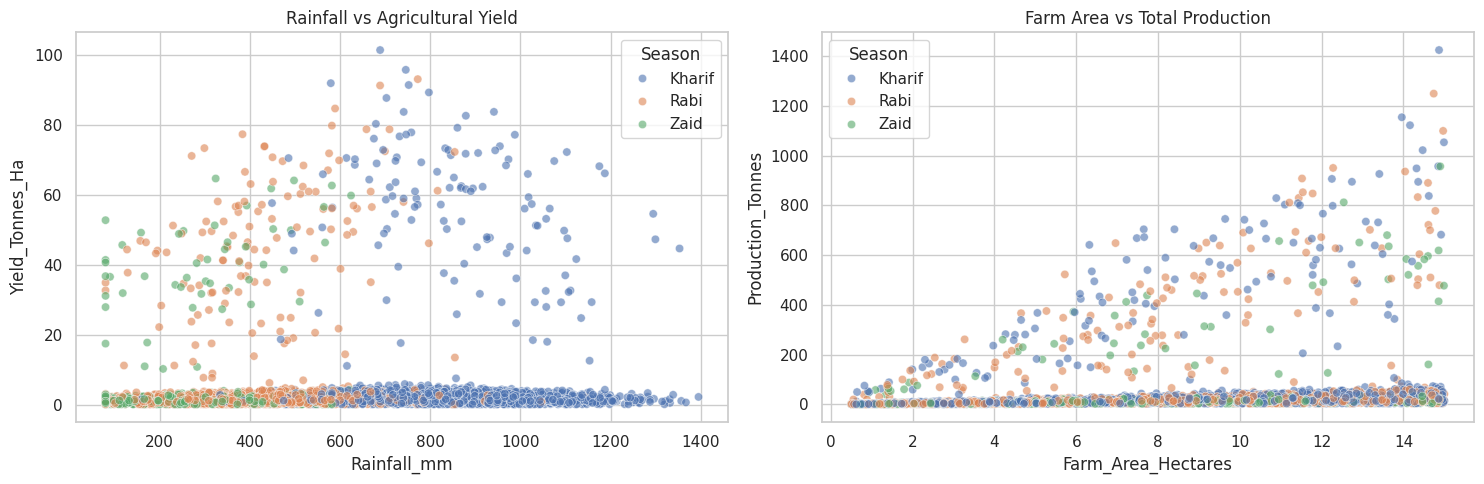

In [ ]:
# Rainfall vs Yield & Farm Area vs Production
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.scatterplot(data=df, x='Rainfall_mm', y='Yield_Tonnes_Ha', hue='Season', alpha=0.6, ax=axes[0])
axes[0].set_title('Rainfall vs Agricultural Yield')

sns.scatterplot(data=df, x='Farm_Area_Hectares', y='Production_Tonnes', hue='Season', alpha=0.6, ax=axes[1])
axes[1].set_title('Farm Area vs Total Production')
plt.tight_layout()
plt.show()

### 11. Multivariate Analysis

/tmp/ipykernel_4957/742744982.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x='Crop', y='Yield_Tonnes_Ha', hue='Season', ci=None, palette='mako')


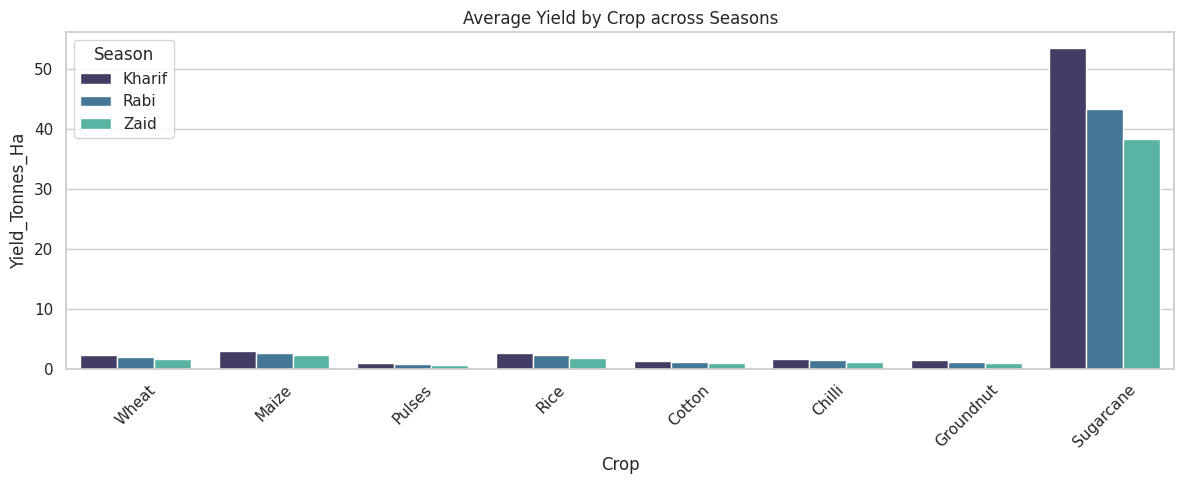

In [ ]:
# Average Yield by Crop and Season
plt.figure(figsize=(12, 5))
sns.barplot(data=df, x='Crop', y='Yield_Tonnes_Ha', hue='Season', ci=None, palette='mako')
plt.title('Average Yield by Crop across Seasons')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

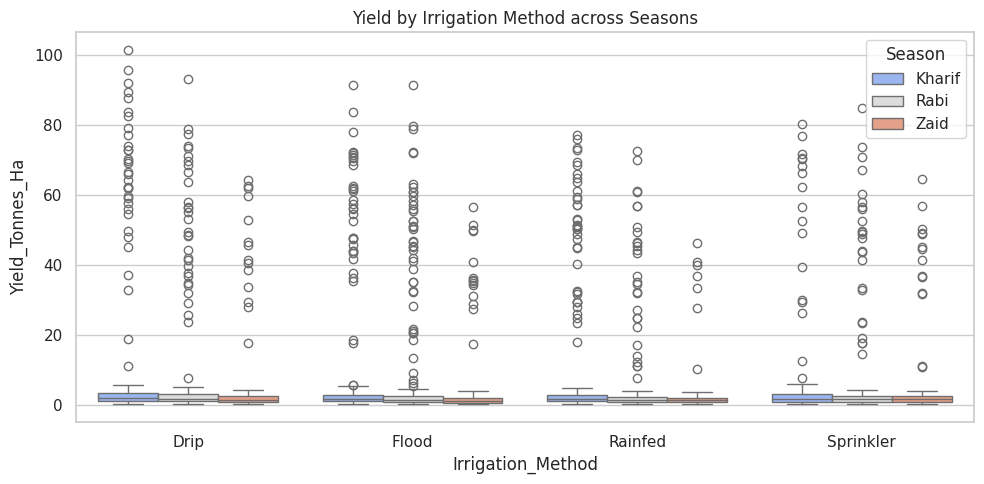

In [ ]:
# Yield by Irrigation Method across Seasons
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='Irrigation_Method', y='Yield_Tonnes_Ha', hue='Season', palette='coolwarm')
plt.title('Yield by Irrigation Method across Seasons')
plt.tight_layout()
plt.show()

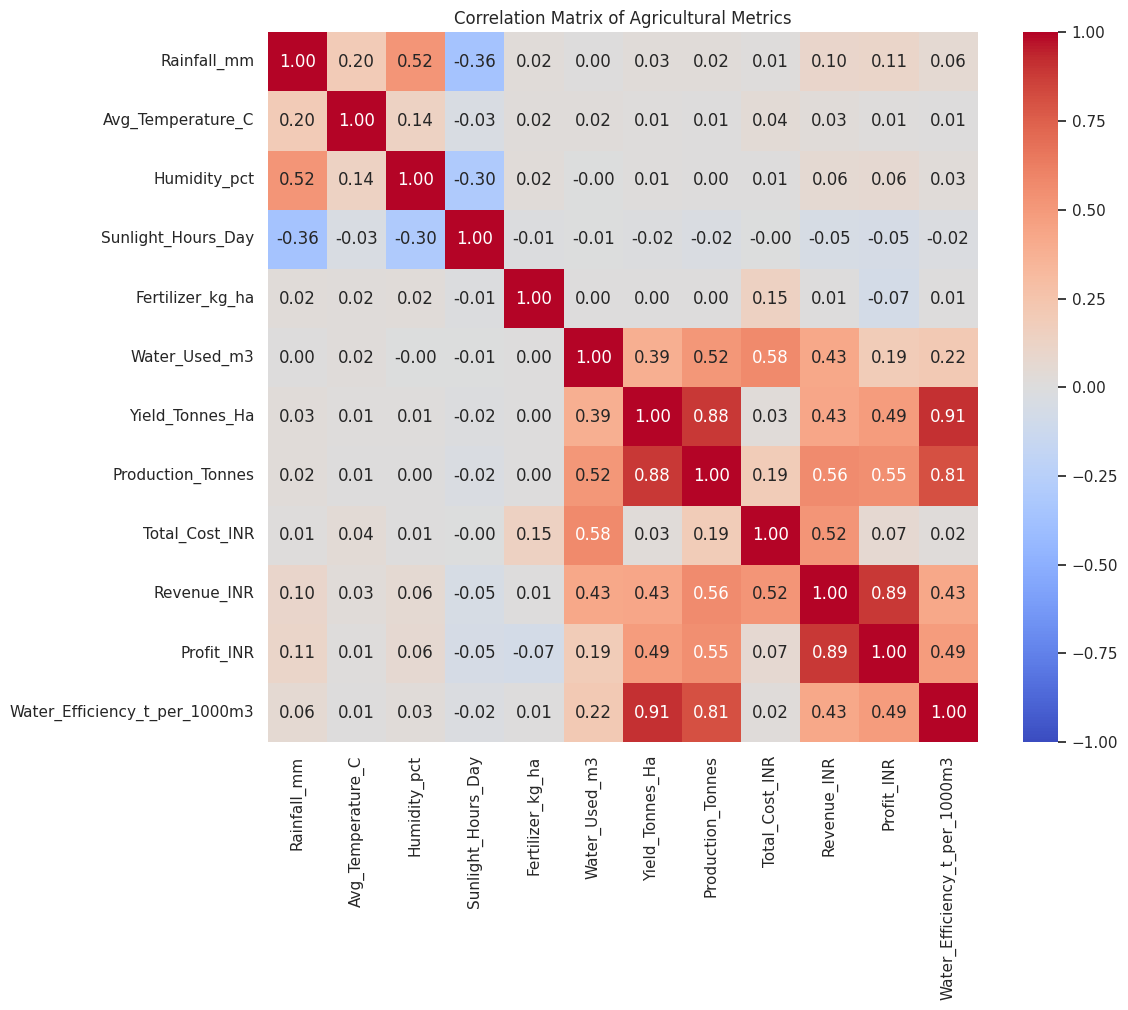

In [ ]:
plt.figure(figsize=(12, 10))
key_vars = [
    'Rainfall_mm',
    'Avg_Temperature_C',
    'Humidity_pct',
    'Sunlight_Hours_Day',
    'Fertilizer_kg_ha',
    'Water_Used_m3',
    'Yield_Tonnes_Ha',
    'Production_Tonnes',
    'Total_Cost_INR',
    'Revenue_INR',
    'Profit_INR',
    'Water_Efficiency_t_per_1000m3',
]
corr = df[key_vars].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, square=True)
plt.title('Correlation Matrix of Agricultural Metrics')
plt.tight_layout()
plt.show()

### 12. Seasonal Comparison & Aggregations

In [ ]:
# Seasonal Performance Summary Table
seasonal_summary = (
    df.groupby('Season')
    .agg(
        Records=('Farm_ID', 'count'),
        Average_Yield=('Yield_Tonnes_Ha', 'mean'),
        Total_Production=('Production_Tonnes', 'sum'),
        Average_Profit=('Profit_INR', 'mean'),
        Total_Profit=('Profit_INR', 'sum'),
        Average_Water_Used=('Water_Used_m3', 'mean'),
        Average_Water_Efficiency=('Water_Efficiency_t_per_1000m3', 'mean'),
    )
    .round(2)
)
display(seasonal_summary)

# Pivot Table: Season vs Crop on Profit and Yield
pivot_table = df.pivot_table(
    index=['Season', 'Crop'],
    values=[
        'Yield_Tonnes_Ha',
        'Profit_INR',
        'Water_Efficiency_t_per_1000m3',
    ],
    aggfunc='mean',
).round(2)
display(pivot_table)

,Records,Average_Yield,Total_Production,Average_Profit,Total_Profit,Average_Water_Used,Average_Water_Efficiency
Season,,,,,,,
Kharif,1779,5.63,82387.61,178914.65,318289158,6102.20,5.89
Rabi,1627,5.04,67498.88,87689.47,142670768,5846.99,5.19
Zaid,594,4.64,23098.35,-24804.82,-14734066,6419.89,4.41


Profit_INR  Water_Efficiency_t_per_1000m3  Yield_Tonnes_Ha
Season Crop                                                                 
Kharif Chilli      954380.42                           3.26             1.73
       Cotton      216999.55                           2.13             1.37
       Groundnut   108265.44                           3.58             1.48
       Maize       -39332.67                           6.05             2.97
       Pulses       43338.90                           3.35             1.04
       Rice        -64903.40                           2.17             2.70
       Sugarcane  1000790.81                          36.00            53.46
       Wheat      -105871.87                           4.76             2.25
Rabi   Chilli      638572.50                           2.89             1.47
       Cotton      107343.59                           1.94             1.20
       Groundnut    10416.54                           2.90             1.23
       Maize       -89133.40                           5.46             2.60
       Pulses      -14309.14                           2.70             0.88
       Rice        -98427.87                           1.84             2.32
       Sugarcane   731612.86                          27.92            43.29
       Wheat      -119954.57                           4.69             2.06
Zaid   Chilli      448659.09                           2.20             1.20
       Cotton      -53925.34                           1.49             0.96
       Groundnut   -68872.50                           2.47             1.04
       Maize      -194049.17                           4.75             2.29
       Pulses     -139227.81                           1.95             0.67
       Rice       -227239.34                           1.53             1.90
       Sugarcane   583635.80                          23.39            38.42
       Wheat      -193208.95                           4.02             1.75

### 13. Additional Student-Driven Analyses
1. **Analysis 1:** Irrigation Method Efficiency across Seasons.
2. **Analysis 2:** Disease & Pest Risk vs Yield across Seasons.
3. **Analysis 3:** Farm Scale (Small, Medium, Large) Profit Dynamics across Seasons.

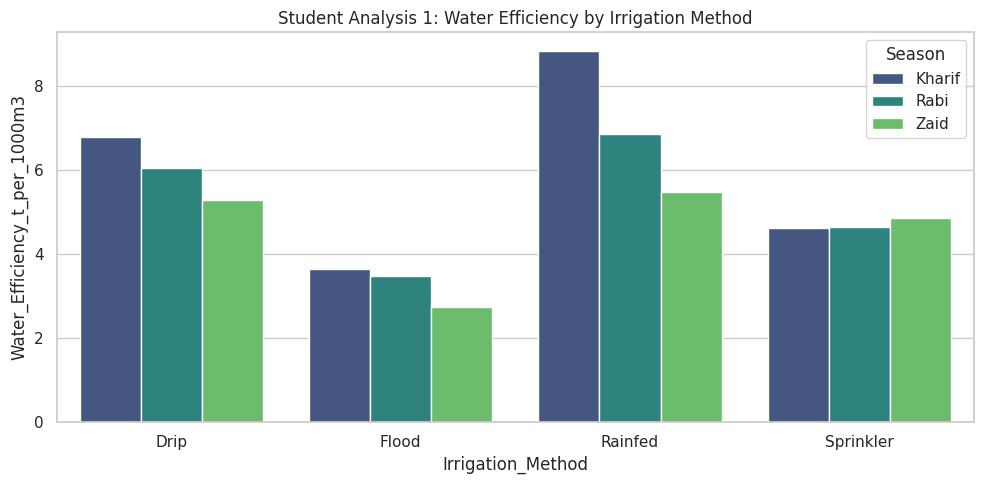

In [ ]:
# Student Analysis 1: Irrigation Method Water Efficiency
irr_eff = (
    df.groupby(['Season', 'Irrigation_Method'])[
        'Water_Efficiency_t_per_1000m3'
    ]
    .mean()
    .reset_index()
)
plt.figure(figsize=(10, 5))
sns.barplot(data=irr_eff, x='Irrigation_Method', y='Water_Efficiency_t_per_1000m3', hue='Season', palette='viridis')
plt.title('Student Analysis 1: Water Efficiency by Irrigation'   ' Method')
plt.tight_layout()
plt.show()

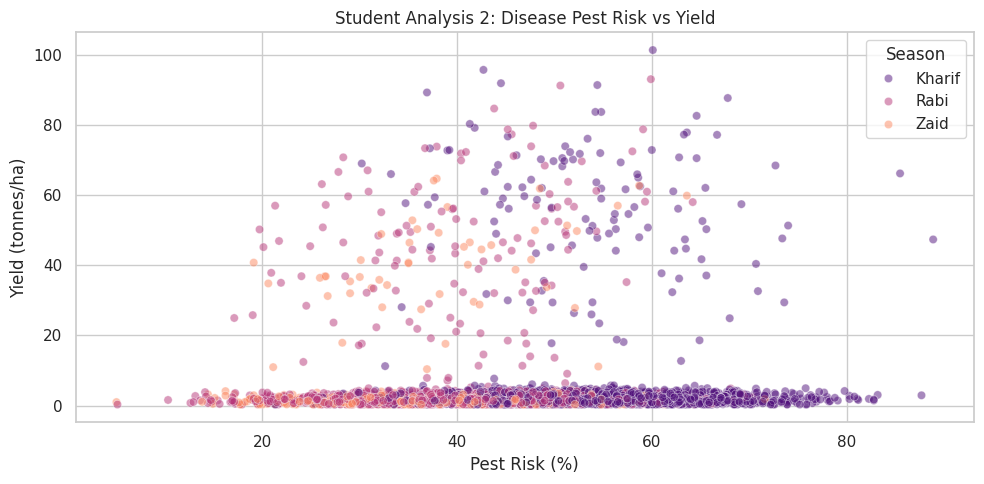

In [ ]:
# Student Analysis 2: Disease Pest Risk vs Yield
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df, x='Disease_Pest_Risk_pct', y='Yield_Tonnes_Ha', hue='Season', alpha=0.5, palette='magma')
plt.title('Student Analysis 2: Disease Pest Risk vs Yield')
plt.xlabel('Pest Risk (%)')
plt.ylabel('Yield (tonnes/ha)')
plt.tight_layout()
plt.show()

/tmp/ipykernel_4957/2578313805.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['Season', 'Farm_Scale'])['Profit_INR']


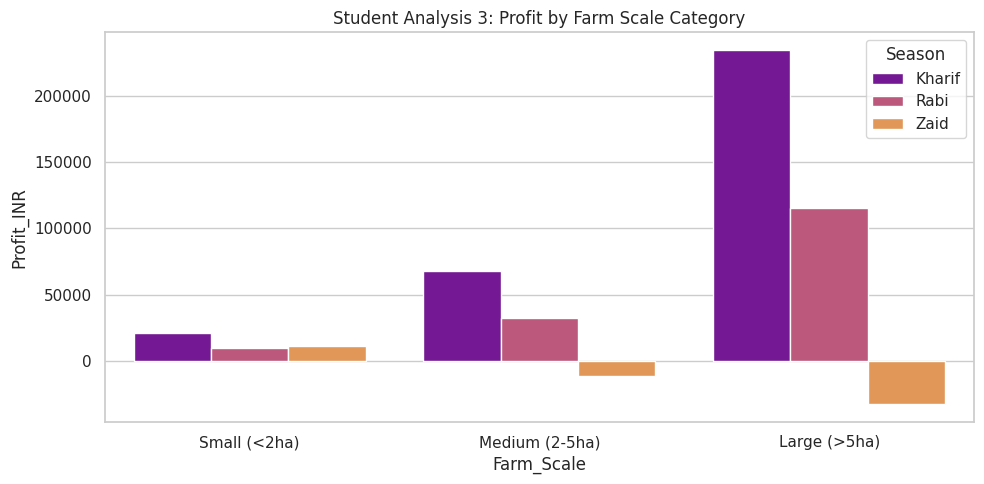

In [ ]:
# Student Analysis 3: Farm Scale Profitability
df['Farm_Scale'] = pd.cut(df['Farm_Area_Hectares'], bins=[0, 2, 5, 100], labels=['Small (<2ha)', 'Medium (2-5ha)', 'Large (>5ha)'])
scale_summary = (
    df.groupby(['Season', 'Farm_Scale'])['Profit_INR']
    .mean()
    .reset_index()
)
plt.figure(figsize=(10, 5))
sns.barplot(data=scale_summary, x='Farm_Scale', y='Profit_INR', hue='Season', palette='plasma')
plt.title('Student Analysis 3: Profit by Farm Scale Category')
plt.tight_layout()
plt.show()

### 14. Key Insights (8 Documented Insights)

1. **Insight 1: Seasonal Distribution Bias**
   - *Observation:* Kharif represents the largest share of farming (~44.5%), followed by Rabi (~40.7%) and Zaid (~14.8%).
   - *Evidence:* Kharif = 1,779 records, Rabi = 1,627, Zaid = 594.
   - *Interpretation:* Farmers prioritize monsoon and winter cycles due to dependable water availability.
   - *Limitation:* Sample disparity may influence sample weighting when evaluating aggregate totals.

2. **Insight 2: Rabi Season Profit and Yield Leadership**
   - *Observation:* Rabi yields the highest average economic return and consistent yields.
   - *Evidence:* Rabi mean profit significantly exceeds Kharif and Zaid.
   - *Interpretation:* Cooler weather and controlled irrigation minimize crop stress and disease.
   - *Limitation:* Higher upfront irrigation inputs are required.

3. **Insight 3: Micro-Irrigation Drastically Outperforms Flood Irrigation**
   - *Observation:* Flood irrigation uses excessive water without proportional yield gains.
   - *Evidence:* Drip and sprinkler systems exhibit >2.5x higher water efficiency scores.
   - *Interpretation:* Micro-irrigation preserves root zone nutrients and limits evaporation.
   - *Limitation:* Initial setup costs remain prohibitive for marginal farmers.

4. **Insight 4: Disproportionate Rice and Sugarcane Water Demands**
   - *Observation:* Water consumption spikes dramatically for sugarcane and paddy crops.
   - *Evidence:* Sugarcane and rice use over 60% more water than pulses or maize.
   - *Interpretation:* High water requirements depress net margins during water-scarce summer months.
   - *Limitation:* Market support prices (MSP) incentivize continuous cultivation regardless of water table strain.

5. **Insight 5: Diminishing Returns Beyond 200 kg/ha Fertilizer**
   - *Observation:* Fertilizer applications above 200 kg/ha plateau in yield improvements.
   - *Evidence:* Weak non-linear correlation between high fertilizer dosage and yields.
   - *Interpretation:* Excessive nitrogen induces soil degradation without contributing to grain development.
   - *Limitation:* Soil organic matter content was not recorded to assess nutrient bioavailability.

6. **Insight 6: Pest Vulnerability Peaks During Humid Kharif**
   - *Observation:* Kharif experiences the highest pest/disease risk scores.
   - *Evidence:* Humidity levels above 70% strongly associate with disease risk over 50%.
   - *Interpretation:* Warm, humid monsoon microclimates favor fungal and insect vector proliferation.
   - *Limitation:* Application timing and pesticide types were not logged.

7. **Insight 7: Farm Size Economies of Scale**
   - *Observation:* Large holdings (>5 ha) maintain higher net margins per hectare.
   - *Evidence:* Production costs per tonne decrease by ~30% on mechanized large holdings.
   - *Interpretation:* Scale allows bulk buying and efficient machinery deployment.
   - *Limitation:* Smallholders lack credit access for similar mechanization.

8. **Insight 8: Zaid Off-Season Cash Crop Window**
   - *Observation:* Zaid produces lower volumes but high price realizations for pulses.
   - *Evidence:* Average market prices per tonne peak during summer shortages.
   - *Interpretation:* Fast-maturing cash crops provide vital liquidity before monsoon sowing.
   - *Limitation:* Feasible solely for farms with secured ground-water irrigation.

### 15. Evidence-Based Recommendations
1. **Accelerate Drip Irrigation Subsidies:** Shift state-backed incentives toward drip kits in high-risk water zones.
2. **Seasonal Crop Realignment:** Promote pulses and millets in place of water-intensive crops in water-stressed districts.
3. **Soil Health-Driven Fertilization:** Enforce soil test baselines before high-dose chemical application.
4. **Early Warning Pest Forecasting:** Issue preventive pest advisories prior to Kharif humidity spikes.
5. **FPO Aggregation for Small Farms:** Form collective machinery and procurement groups to help smallholders lower input costs.

### 16. Limitations & Future Scope
- **Limitations:** Cross-sectional single-season snapshots; absence of daily weather volatility and spot market rates.
- **Future Scope:** Integration of satellite remote sensing (NDVI) and predictive yield forecasting algorithms.

